# Stage 1 - lambda 5 wrapped run analysis (trimmed years)

Loads the wrapped multi-year sequence output, drops the repeated burn-in and burn-out boundary years using `_sequence_manifest.csv`, and visualizes the retained analysis years separately.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RUN_NAME = "stagel_3month_wrapped_1985_1988"
RUN_LABEL = "lambda5_wrapped_trimmed"

output_root = Path("acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019")
if not output_root.exists():
    output_root = Path.cwd().parent / "outputs" / "historical_1980_2019"

RUN_DIR = output_root / RUN_NAME
MANIFEST_PATH = RUN_DIR / "_sequence_manifest.csv"

print("RUN_NAME:", RUN_NAME)
print("RUN_DIR:", RUN_DIR)
print("MANIFEST_PATH:", MANIFEST_PATH)


RUN_NAME: stagel_3month_wrapped_1985_1988
RUN_DIR: /home/fs01/jl2966/acorn-julia2/acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019/stagel_3month_wrapped_1985_1988
MANIFEST_PATH: /home/fs01/jl2966/acorn-julia2/acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019/stagel_3month_wrapped_1985_1988/_sequence_manifest.csv


In [2]:
# --- Helpers ----------------------------------------------------------------

def _strip_tz(idx):
    if hasattr(idx, 'tz') and idx.tz is not None:
        return idx.tz_convert(None)
    return idx


def _empty_tidy(value_name: str, extra_cols=None) -> pd.DataFrame:
    extra_cols = extra_cols or []
    data = {c: pd.Series(dtype=float) for c in extra_cols + [value_name]}
    data["timestamp"] = pd.to_datetime([])
    return pd.DataFrame(data)


def tidy_storage_df(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    meta_cols = [c for c in ["bus_id", "asset_type", "zone", "is_seasonal"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def tidy_storage_path(path: Path, value_name: str) -> pd.DataFrame:
    if not path.exists():
        return _empty_tidy(value_name)
    return tidy_storage_df(pd.read_csv(path), value_name)


def tidy_bus_df(path: Path, value_name: str) -> pd.DataFrame:
    if not path.exists():
        return _empty_tidy(value_name, extra_cols=["bus_id"])
    df = pd.read_csv(path)
    meta_cols = [c for c in ["bus_id", "zone"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def total_ts(df: pd.DataFrame, value_name: str) -> pd.Series:
    if df is None or df.empty:
        return pd.Series(dtype=float)
    return df.groupby("timestamp")[value_name].sum()


def load_seasonal_soc_token(run_dir: Path, token: str) -> pd.Series:
    p = run_dir / f"storage_state_seasonal_{token}.csv"
    if not p.exists():
        return pd.Series(dtype=float)
    df = pd.read_csv(p)
    if df.empty:
        return pd.Series(dtype=float)
    cols = [c for c in df.columns if c not in ("zone",)]
    df = df[cols]
    if not df.empty and df.iloc[0, 0] == "bus_id":
        df = df.iloc[1:]
    value_cols = [c for c in df.columns if c != "bus_id"]
    df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")
    soc = df[value_cols].sum(axis=0)
    soc.index = pd.to_datetime(soc.index, errors="coerce")
    soc = soc.dropna()
    if hasattr(soc.index, 'tz') and soc.index.tz is not None:
        soc.index = soc.index.tz_convert(None)
    return soc


def safe_sum(series: pd.Series) -> float:
    return pd.to_numeric(series, errors="coerce").fillna(0.0).sum()


def concat_tidy(dfs: list[pd.DataFrame], value_name: str, extra_cols=None) -> pd.DataFrame:
    dfs = [d for d in dfs if d is not None and not d.empty]
    if not dfs:
        return _empty_tidy(value_name, extra_cols=extra_cols)
    return pd.concat(dfs, ignore_index=True)


def concat_series(series_list: list[pd.Series]) -> pd.Series:
    series_list = [s for s in series_list if s is not None and len(s) > 0]
    if not series_list:
        return pd.Series(dtype=float)
    return pd.concat(series_list).sort_index()


def load_manifest(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "keep_for_analysis" in df.columns:
        df["keep_for_analysis"] = pd.to_numeric(df["keep_for_analysis"], errors="coerce").fillna(0).astype(int)
        df = df[df["keep_for_analysis"] == 1].copy()
    df["seq_idx"] = pd.to_numeric(df["seq_idx"], errors="coerce").astype(int)
    df["sim_year"] = pd.to_numeric(df["sim_year"], errors="coerce").astype(int)
    if "analysis_year_idx" in df.columns:
        df["analysis_year_idx"] = pd.to_numeric(df["analysis_year_idx"], errors="coerce").fillna(0).astype(int)
    return df.sort_values("seq_idx").reset_index(drop=True)


def load_run_token(run_dir: Path, token: str) -> dict:
    return {
        "charge_base": tidy_storage_path(run_dir / f"charge_base_{token}.csv", "charge"),
        "discharge_base": tidy_storage_path(run_dir / f"discharge_base_{token}.csv", "discharge"),
        "charge_seasonal": tidy_storage_path(run_dir / f"charge_seasonal_{token}.csv", "charge"),
        "discharge_seasonal": tidy_storage_path(run_dir / f"discharge_seasonal_{token}.csv", "discharge"),
        "load_shed": tidy_bus_df(run_dir / f"load_shedding_{token}.csv", "load_shedding"),
        "wind_curt": tidy_bus_df(run_dir / f"wind_curtailment_{token}.csv", "wind_curtailment"),
        "solar_curt": tidy_bus_df(run_dir / f"solar_curtailment_{token}.csv", "solar_curtailment"),
        "soc_seasonal": load_seasonal_soc_token(run_dir, token),
    }


In [3]:
# --- Load retained analysis years from sequence manifest --------------------
manifest = load_manifest(MANIFEST_PATH)
YEARS = manifest["sim_year"].tolist()
TOKENS = manifest["token"].tolist()

print("Trimmed manifest used for analysis:")
display(manifest)
print("Using analysis years:", YEARS)
print("Using analysis tokens:", TOKENS)

run_data_by_year = {RUN_NAME: {}}
for _, row in manifest.iterrows():
    year = int(row["sim_year"])
    token = row["token"]
    run_data_by_year[RUN_NAME][year] = load_run_token(RUN_DIR, token)

run_data = {
    RUN_NAME: {
        "charge_base": concat_tidy([run_data_by_year[RUN_NAME][y]["charge_base"] for y in YEARS], "charge"),
        "discharge_base": concat_tidy([run_data_by_year[RUN_NAME][y]["discharge_base"] for y in YEARS], "discharge"),
        "charge_seasonal": concat_tidy([run_data_by_year[RUN_NAME][y]["charge_seasonal"] for y in YEARS], "charge"),
        "discharge_seasonal": concat_tidy([run_data_by_year[RUN_NAME][y]["discharge_seasonal"] for y in YEARS], "discharge"),
        "load_shed": concat_tidy([run_data_by_year[RUN_NAME][y]["load_shed"] for y in YEARS], "load_shedding", extra_cols=["bus_id"]),
        "wind_curt": concat_tidy([run_data_by_year[RUN_NAME][y]["wind_curt"] for y in YEARS], "wind_curtailment", extra_cols=["bus_id"]),
        "solar_curt": concat_tidy([run_data_by_year[RUN_NAME][y]["solar_curt"] for y in YEARS], "solar_curtailment", extra_cols=["bus_id"]),
        "soc_seasonal": concat_series([run_data_by_year[RUN_NAME][y]["soc_seasonal"] for y in YEARS]),
    }
}

RUNS = [RUN_NAME]
LABELS = {RUN_NAME: RUN_LABEL}
print("Loaded run:", RUNS)


Trimmed manifest used for analysis:


,seq_idx,sim_year,token,prev_token,sequence_role,keep_for_analysis,analysis_year_idx
0,2,1985,seq002_y1985,seq001_y1985,analysis,1,1
1,3,1986,seq003_y1986,seq002_y1985,analysis,1,2
2,4,1987,seq004_y1987,seq003_y1986,analysis,1,3
3,5,1988,seq005_y1988,seq004_y1987,analysis,1,4


Using analysis years: [1985, 1986, 1987, 1988]
Using analysis tokens: ['seq002_y1985', 'seq003_y1986', 'seq004_y1987', 'seq005_y1988']
Loaded run: ['stagel_3month_wrapped_1985_1988']


## A) Annual totals (energy, curtailment, load shedding)


In [4]:
# --- Summary totals across all selected years -----------------------------
rows = []
for run, data in run_data.items():
    label = LABELS.get(run, run)
    base_dis = total_ts(data["discharge_base"], "discharge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    base_ch = total_ts(data["charge_base"], "charge")
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    ls = total_ts(data["load_shed"], "load_shedding")
    wind = total_ts(data["wind_curt"], "wind_curtailment")
    solar = total_ts(data["solar_curt"], "solar_curtailment")

    rows.append({
        "run": label,
        "base_charge_MWh": safe_sum(base_ch),
        "base_discharge_MWh": safe_sum(base_dis),
        "seasonal_charge_MWh": safe_sum(seas_ch),
        "seasonal_discharge_MWh": safe_sum(seas_dis),
        "load_shed_MWh": safe_sum(ls),
        "wind_curt_MWh": safe_sum(wind),
        "solar_curt_MWh": safe_sum(solar),
    })

summary_df = pd.DataFrame(rows)
for c in summary_df.columns[1:]:
    summary_df[c] = summary_df[c].round(2)

display(summary_df)

# --- Per-year summary -------------------------------------------------------
rows = []
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        base_dis = total_ts(data["discharge_base"], "discharge")
        seas_dis = total_ts(data["discharge_seasonal"], "discharge")
        base_ch = total_ts(data["charge_base"], "charge")
        seas_ch = total_ts(data["charge_seasonal"], "charge")
        ls = total_ts(data["load_shed"], "load_shedding")
        wind = total_ts(data["wind_curt"], "wind_curtailment")
        solar = total_ts(data["solar_curt"], "solar_curtailment")

        rows.append({
            "run": label,
            "year": year,
            "base_charge_MWh": safe_sum(base_ch),
            "base_discharge_MWh": safe_sum(base_dis),
            "seasonal_charge_MWh": safe_sum(seas_ch),
            "seasonal_discharge_MWh": safe_sum(seas_dis),
            "load_shed_MWh": safe_sum(ls),
            "wind_curt_MWh": safe_sum(wind),
            "solar_curt_MWh": safe_sum(solar),
        })

year_df = pd.DataFrame(rows)
if not year_df.empty:
    for c in year_df.columns[2:]:
        year_df[c] = year_df[c].round(2)
    display(year_df.sort_values(["year", "run"]))


,run,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh
0,lambda5_wrapped_trimmed,1203100.92,902325.69,356969.74,755461.35,2236446.45,26070552.72,41516434.23


,run,year,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh
0,lambda5_wrapped_trimmed,1985,323469.34,242602.00,0.00,185267.67,637186.45,7083429.75,10686128.29
1,lambda5_wrapped_trimmed,1986,291369.53,218527.14,0.00,80542.05,362142.50,6919586.29,10889632.04
2,lambda5_wrapped_trimmed,1987,310925.52,233194.14,159116.74,239483.82,574473.06,5452036.41,9983394.14
3,lambda5_wrapped_trimmed,1988,277336.54,208002.40,197853.00,250167.81,662644.45,6615500.27,9957279.77


## B) Storage activity (base vs seasonal)


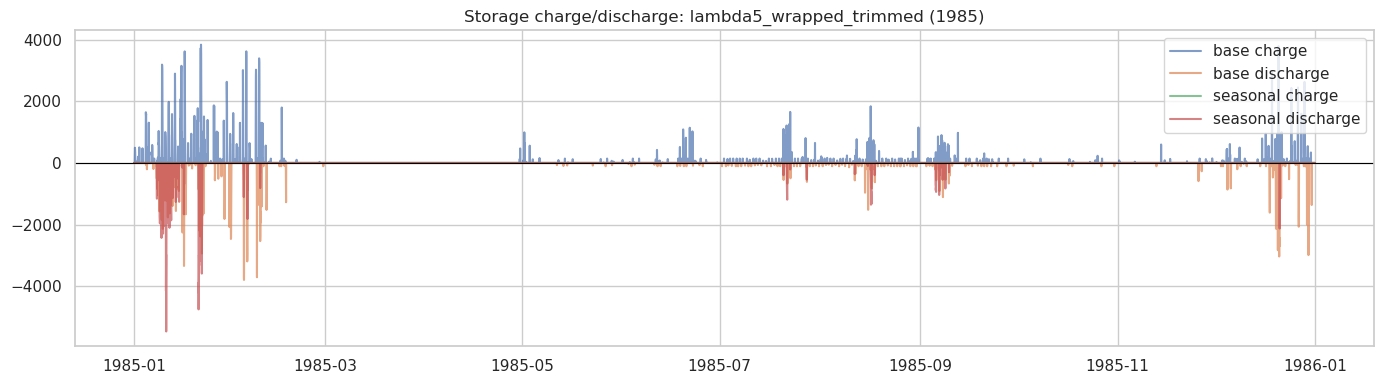

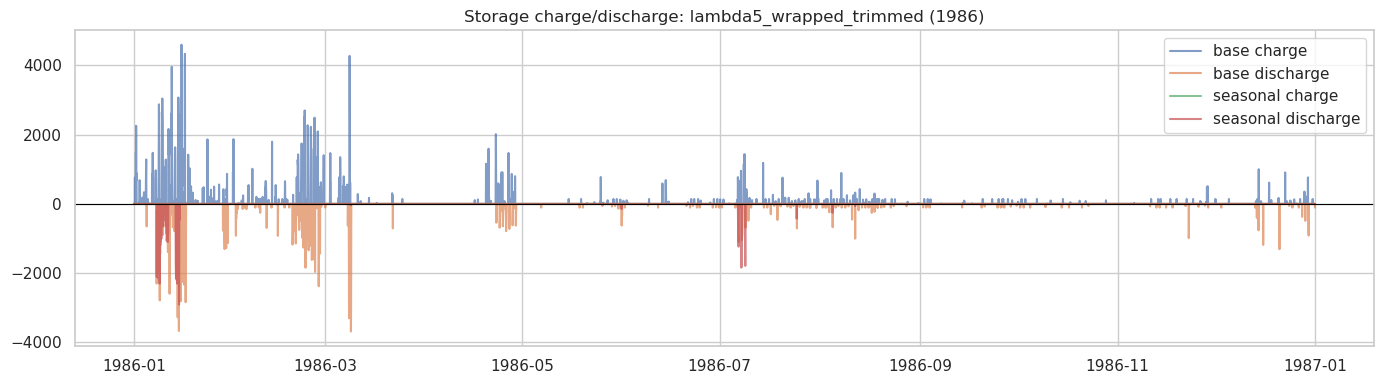

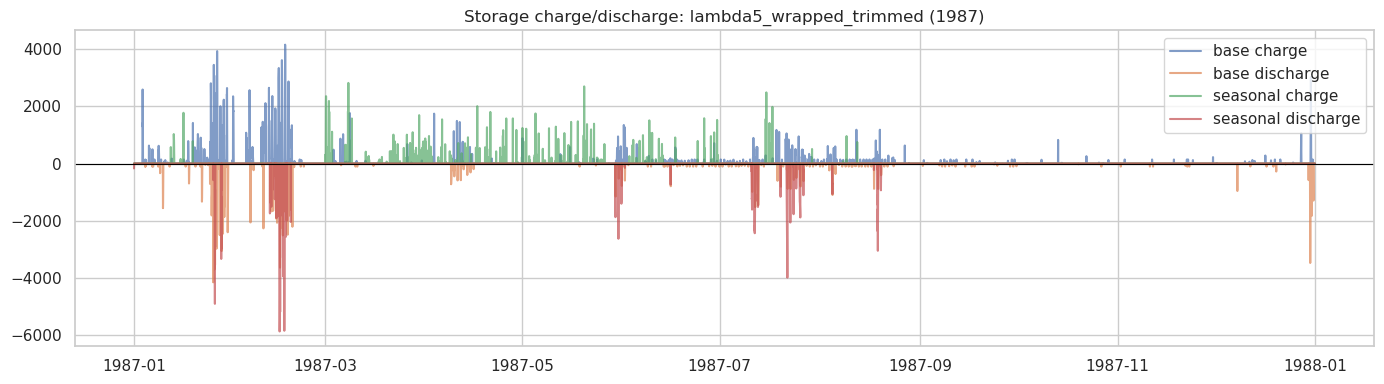

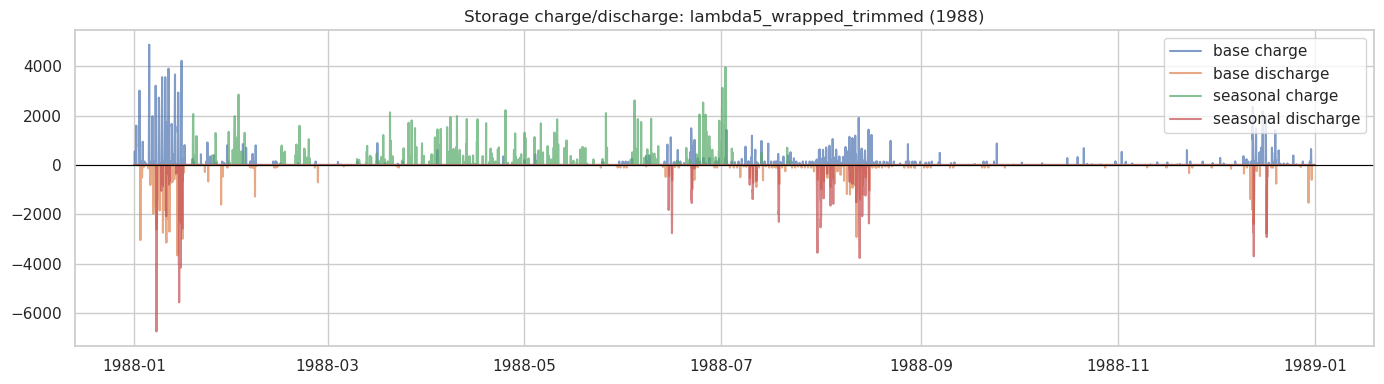

In [5]:
# --- Storage charge/discharge timeseries (show each retained year) ----------
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        base_ch = total_ts(data["charge_base"], "charge")
        base_dis = total_ts(data["discharge_base"], "discharge")
        seas_ch = total_ts(data["charge_seasonal"], "charge")
        seas_dis = total_ts(data["discharge_seasonal"], "discharge")

        if base_ch.empty and base_dis.empty and seas_ch.empty and seas_dis.empty:
            continue

        fig, ax = plt.subplots(1, 1, figsize=(14,4))
        ax.plot(base_ch.index, base_ch.values, label="base charge", alpha=0.7)
        ax.plot(base_dis.index, -base_dis.values, label="base discharge", alpha=0.7)
        ax.plot(seas_ch.index, seas_ch.values, label="seasonal charge", alpha=0.7)
        ax.plot(seas_dis.index, -seas_dis.values, label="seasonal discharge", alpha=0.7)
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.set_title(f"Storage charge/discharge: {label} ({year})")
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()


## C) Load shedding (time series + top buses)


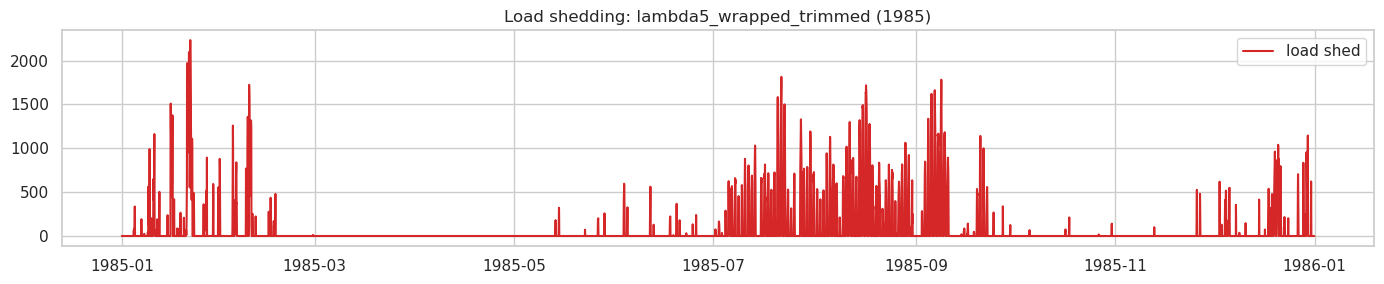

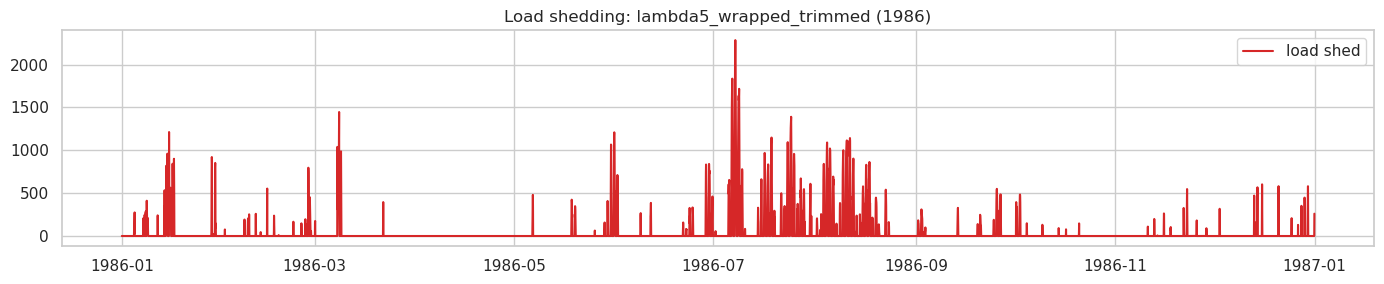

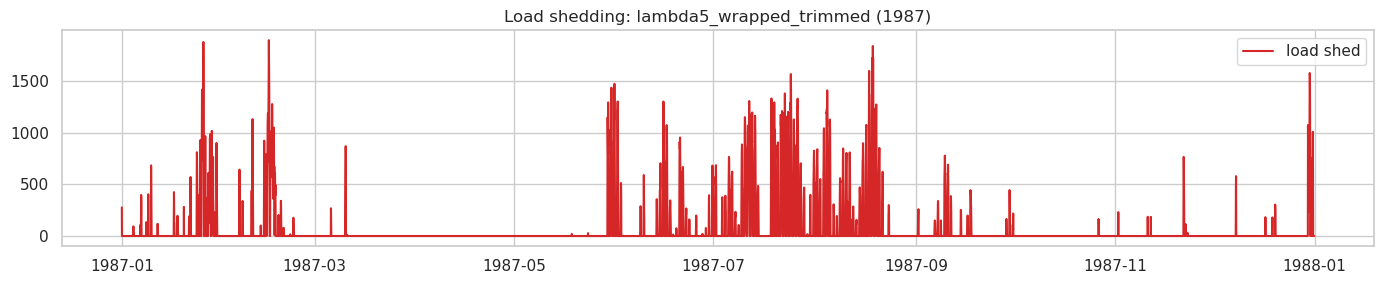

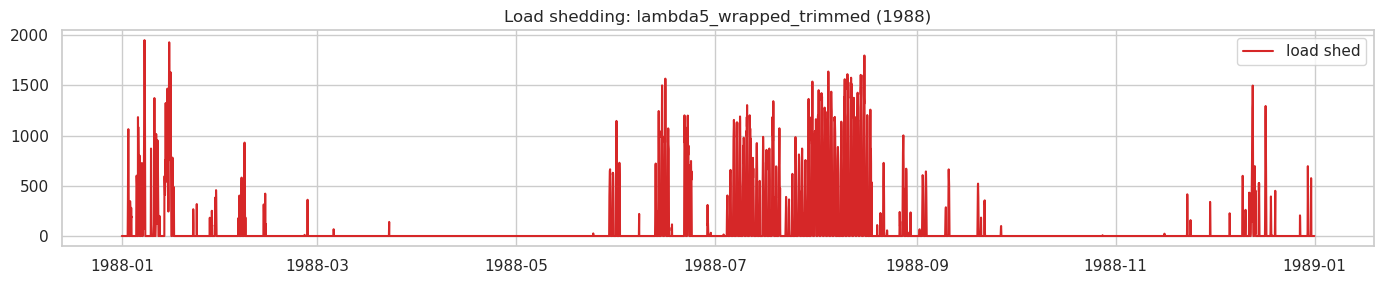

lambda5_wrapped_trimmed - top 15 shedding buses (trimmed retained years)


,bus_id,load_shedding
0,80,2.236446e+06
1,37,0.000000e+00
2,39,0.000000e+00
3,40,0.000000e+00
4,41,0.000000e+00
5,38,0.000000e+00
6,43,0.000000e+00
7,44,0.000000e+00
8,45,0.000000e+00
9,46,0.000000e+00


In [6]:
# --- Load shedding (show each retained year) --------------------------------
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        ls = total_ts(data["load_shed"], "load_shedding")
        if ls.empty:
            continue
        fig, ax = plt.subplots(1, 1, figsize=(14,3))
        ax.plot(ls.index, ls.values, label="load shed", color="tab:red")
        ax.set_title(f"Load shedding: {label} ({year})")
        ax.legend()
        plt.tight_layout()
        plt.show()

# Top shedding buses across all retained years
for run, data in run_data.items():
    label = LABELS.get(run, run)
    if data["load_shed"].empty:
        print(f"{label}: no load shedding data")
        continue
    ls_bus = data["load_shed"].groupby("bus_id")["load_shedding"].sum().sort_values(ascending=False).head(15)
    print(f"{label} - top 15 shedding buses (trimmed retained years)")
    display(ls_bus.reset_index())


## D) Curtailment (wind + solar)


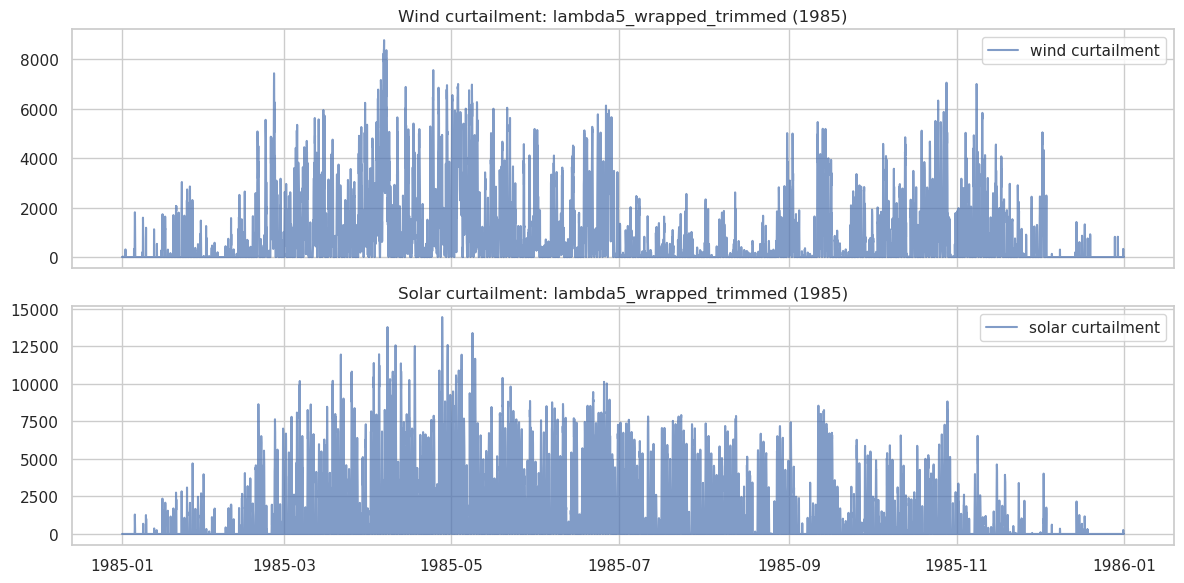

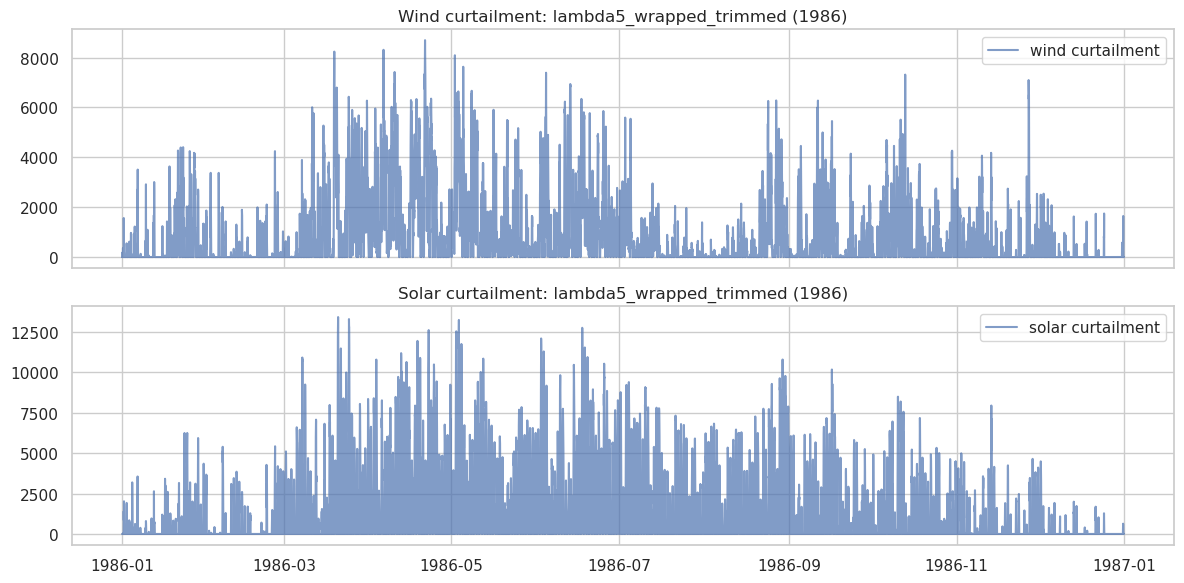

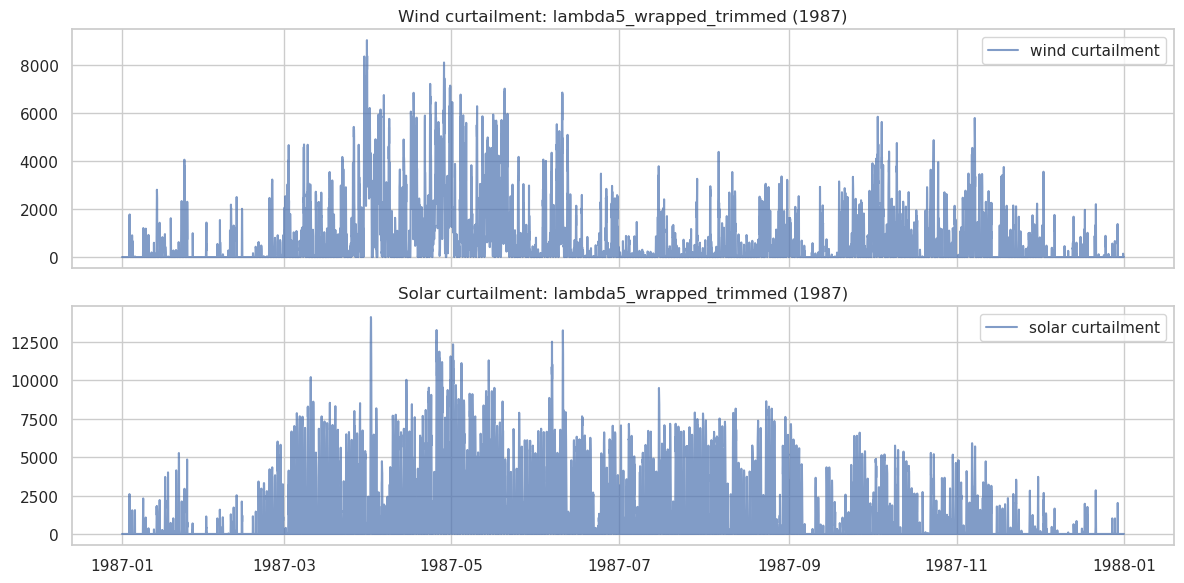

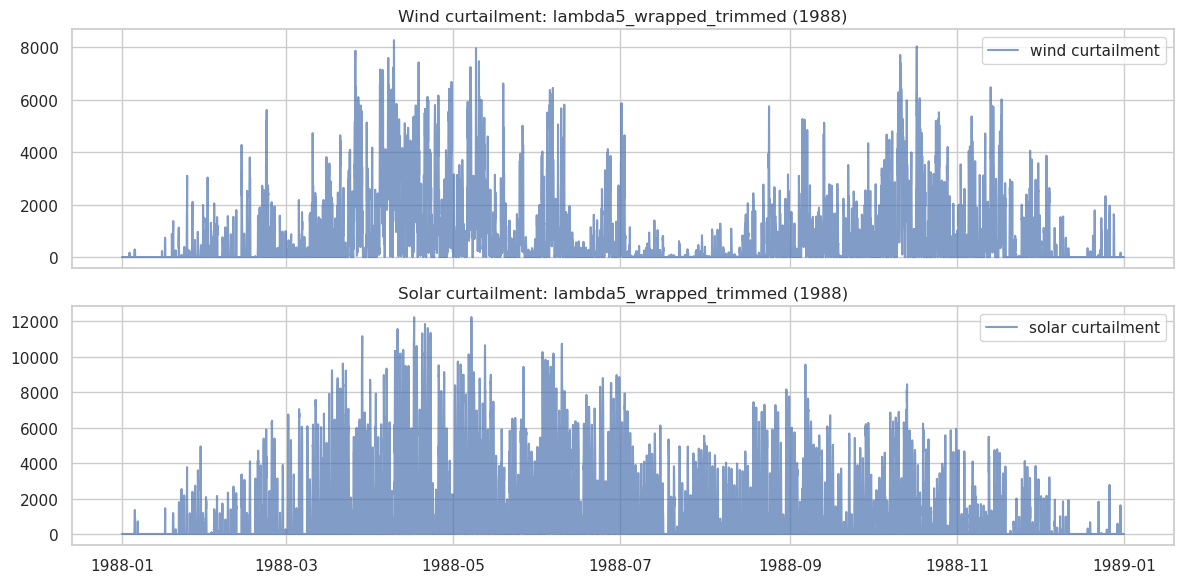

In [7]:
# --- Curtailment (show each retained year) ----------------------------------
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        wind = total_ts(data["wind_curt"], "wind_curtailment")
        solar = total_ts(data["solar_curt"], "solar_curtailment")

        fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)
        axes[0].plot(wind.index, wind.values, label="wind curtailment", alpha=0.7)
        axes[0].set_title(f"Wind curtailment: {label} ({year})")
        axes[0].legend()

        axes[1].plot(solar.index, solar.values, label="solar curtailment", alpha=0.7)
        axes[1].set_title(f"Solar curtailment: {label} ({year})")
        axes[1].legend()

        plt.tight_layout()
        plt.show()


## E) Seasonal SOC stats + monthly seasonality


,run,soc_max_MWh,soc_min_MWh,soc_end_MWh
0,lambda5_wrapped_trimmed,3655038.98,3091852.22,3091852.22


,run,year,soc_max_MWh,soc_min_MWh,soc_end_MWh
0,lambda5_wrapped_trimmed,1985,3655038.98,3441110.30,3441110.30
1,lambda5_wrapped_trimmed,1986,3441110.30,3348108.36,3348108.36
2,lambda5_wrapped_trimmed,1987,3356400.73,3209375.41,3209375.41
3,lambda5_wrapped_trimmed,1988,3256606.30,3091852.22,3091852.22


Daily net seasonal energy (MWh) - lambda5_wrapped_trimmed (1985):


,net_MWh
timestamp,
1985-01-01,0.0
1985-01-02,0.0
1985-01-03,0.0
1985-01-04,0.0
1985-01-05,0.0
...,...
1985-12-27,0.0
1985-12-28,0.0
1985-12-29,0.0


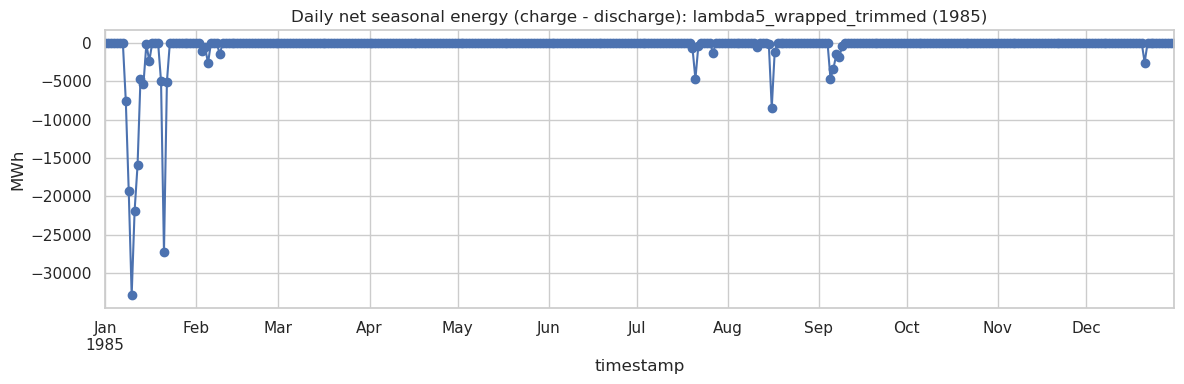

Daily mean seasonal SOC (MWh) - lambda5_wrapped_trimmed (1985):


,soc_MWh
1985-01-01,3655039.0
1985-01-02,3655039.0
1985-01-03,3655039.0
1985-01-04,3655039.0
1985-01-05,3655039.0
...,...
1985-12-27,3441110.3
1985-12-28,3441110.3
1985-12-29,3441110.3
1985-12-30,3441110.3


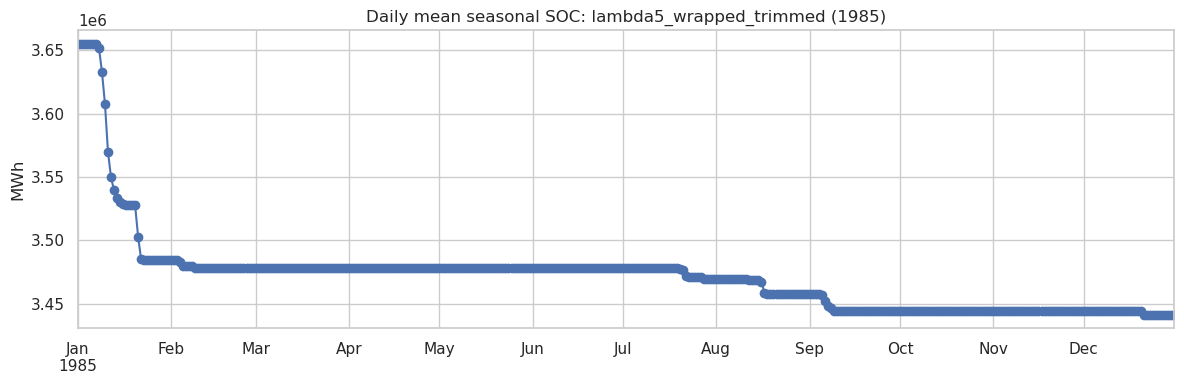

Daily net seasonal energy (MWh) - lambda5_wrapped_trimmed (1986):


,net_MWh
timestamp,
1986-01-01,0.0
1986-01-02,0.0
1986-01-03,0.0
1986-01-04,0.0
1986-01-05,0.0
...,...
1986-12-27,0.0
1986-12-28,0.0
1986-12-29,0.0


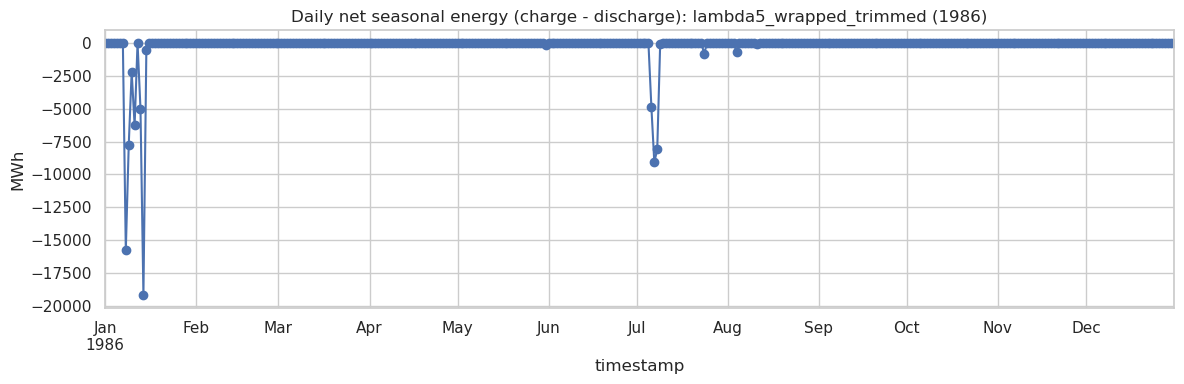

Daily mean seasonal SOC (MWh) - lambda5_wrapped_trimmed (1986):


,soc_MWh
1986-01-01,3441110.3
1986-01-02,3441110.3
1986-01-03,3441110.3
1986-01-04,3441110.3
1986-01-05,3441110.3
...,...
1986-12-27,3348108.4
1986-12-28,3348108.4
1986-12-29,3348108.4
1986-12-30,3348108.4


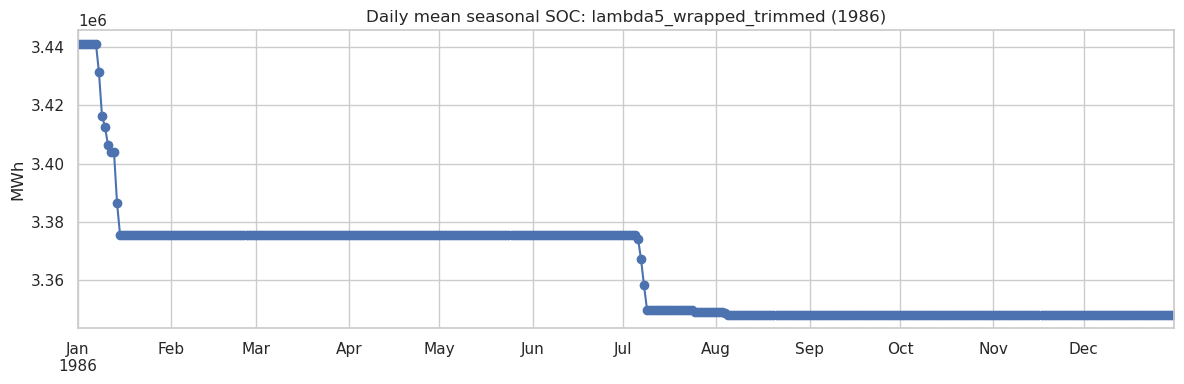

Daily net seasonal energy (MWh) - lambda5_wrapped_trimmed (1987):


,net_MWh
timestamp,
1987-01-01,-171.4
1987-01-02,0.0
1987-01-03,0.0
1987-01-04,0.0
1987-01-05,0.0
...,...
1987-12-27,0.0
1987-12-28,0.0
1987-12-29,0.0


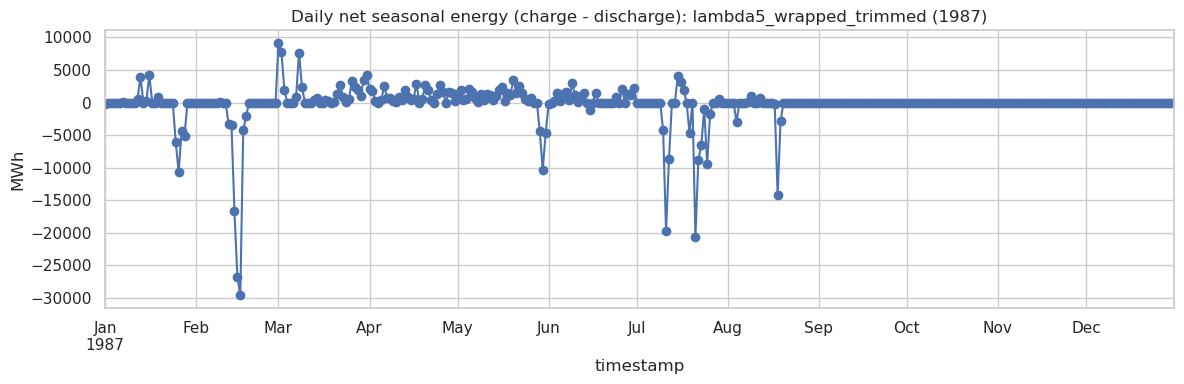

Daily mean seasonal SOC (MWh) - lambda5_wrapped_trimmed (1987):


,soc_MWh
1987-01-01,3347918.7
1987-01-02,3347910.4
1987-01-03,3347910.4
1987-01-04,3347910.4
1987-01-05,3347910.4
...,...
1987-12-27,3209375.4
1987-12-28,3209375.4
1987-12-29,3209375.4
1987-12-30,3209375.4


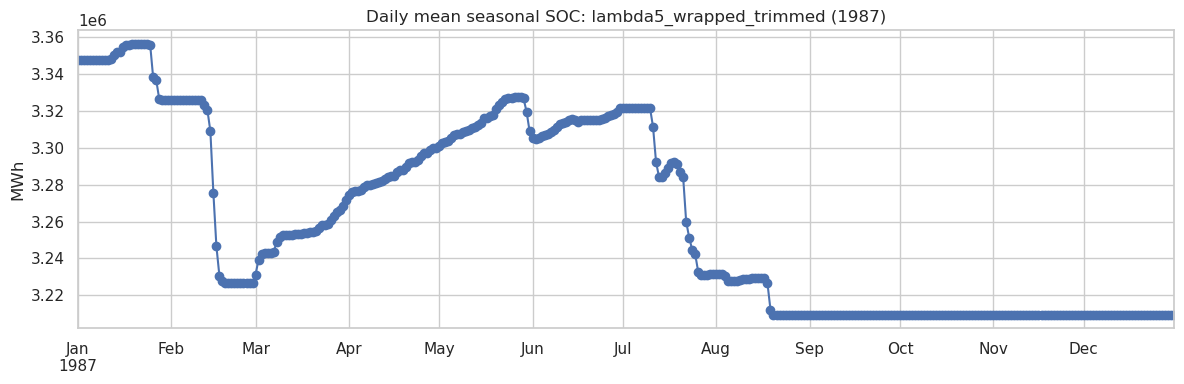

Daily net seasonal energy (MWh) - lambda5_wrapped_trimmed (1988):


,net_MWh
timestamp,
1988-01-01,0.0
1988-01-02,0.0
1988-01-03,0.0
1988-01-04,0.0
1988-01-05,0.0
...,...
1988-12-27,0.0
1988-12-28,0.0
1988-12-29,0.0


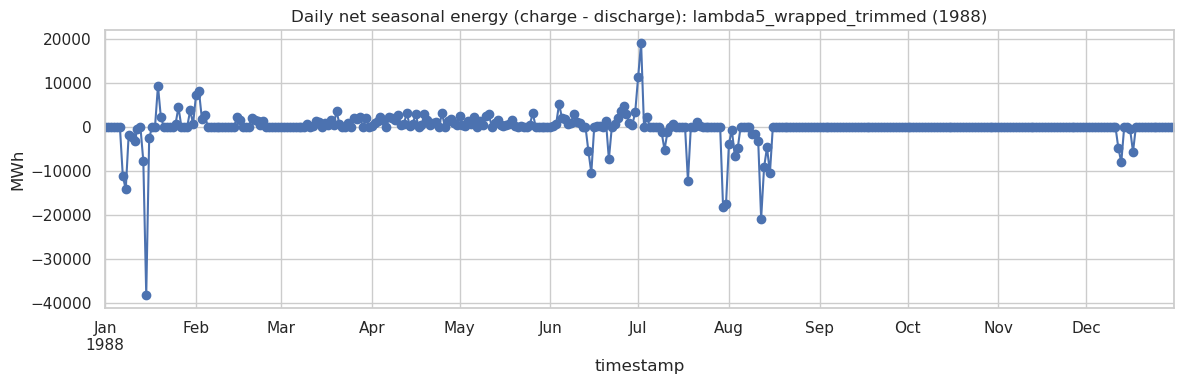

Daily mean seasonal SOC (MWh) - lambda5_wrapped_trimmed (1988):


,soc_MWh
1988-01-01,3209375.4
1988-01-02,3209375.4
1988-01-03,3209375.4
1988-01-04,3209375.4
1988-01-05,3209375.4
...,...
1988-12-27,3091852.2
1988-12-28,3091852.2
1988-12-29,3091852.2
1988-12-30,3091852.2


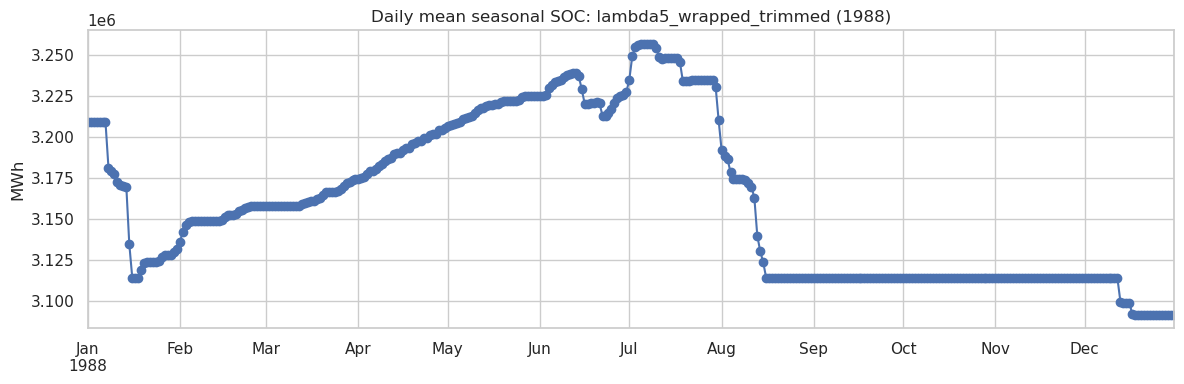

In [8]:
# --- Seasonal SOC summary ---------------------------------------------------
rows = []
for run, data in run_data.items():
    label = LABELS.get(run, run)
    soc = data["soc_seasonal"]
    if soc.empty:
        rows.append({"run": label, "soc_max_MWh": np.nan, "soc_min_MWh": np.nan, "soc_end_MWh": np.nan})
        continue
    rows.append({
        "run": label,
        "soc_max_MWh": float(soc.max()),
        "soc_min_MWh": float(soc.min()),
        "soc_end_MWh": float(soc.iloc[-1]),
    })

soc_df = pd.DataFrame(rows)
for c in soc_df.columns[1:]:
    soc_df[c] = soc_df[c].round(2)

display(soc_df)

# Per-year SOC summary
rows = []
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        soc = data["soc_seasonal"]
        if soc.empty:
            rows.append({"run": label, "year": year, "soc_max_MWh": np.nan, "soc_min_MWh": np.nan, "soc_end_MWh": np.nan})
            continue
        rows.append({
            "run": label,
            "year": year,
            "soc_max_MWh": float(soc.max()),
            "soc_min_MWh": float(soc.min()),
            "soc_end_MWh": float(soc.iloc[-1]),
        })

soc_year_df = pd.DataFrame(rows)
if not soc_year_df.empty:
    for c in soc_year_df.columns[2:]:
        soc_year_df[c] = soc_year_df[c].round(2)
    display(soc_year_df.sort_values(["year", "run"]))

# Daily net energy + SOC, shown year-by-year

def daily_sum(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("D").sum()


def daily_mean(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("D").mean()

for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        seas_ch = total_ts(data["charge_seasonal"], "charge")
        seas_dis = total_ts(data["discharge_seasonal"], "discharge")
        net = seas_ch - seas_dis
        daily_net = daily_sum(net)
        daily_soc = daily_mean(data["soc_seasonal"])

        print(f"Daily net seasonal energy (MWh) - {label} ({year}):")
        display(daily_net.round(1).to_frame(name="net_MWh"))
        if not daily_net.empty:
            ax = daily_net.plot(figsize=(12,4), marker='o', title=f"Daily net seasonal energy (charge - discharge): {label} ({year})")
            ax.set_ylabel("MWh")
            plt.tight_layout()
            plt.show()

        print(f"Daily mean seasonal SOC (MWh) - {label} ({year}):")
        display(daily_soc.round(1).to_frame(name="soc_MWh"))
        if not daily_soc.empty:
            ax = daily_soc.plot(figsize=(12,4), marker='o', title=f"Daily mean seasonal SOC: {label} ({year})")
            ax.set_ylabel("MWh")
            plt.tight_layout()
            plt.show()


lambda5_wrapped_trimmed (1985) simultaneous hours: 0, days: 0


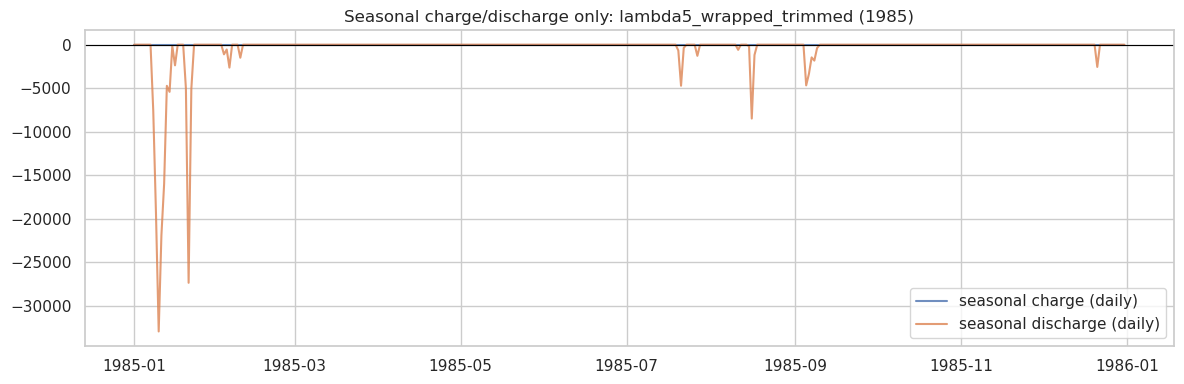

lambda5_wrapped_trimmed (1986) simultaneous hours: 0, days: 0


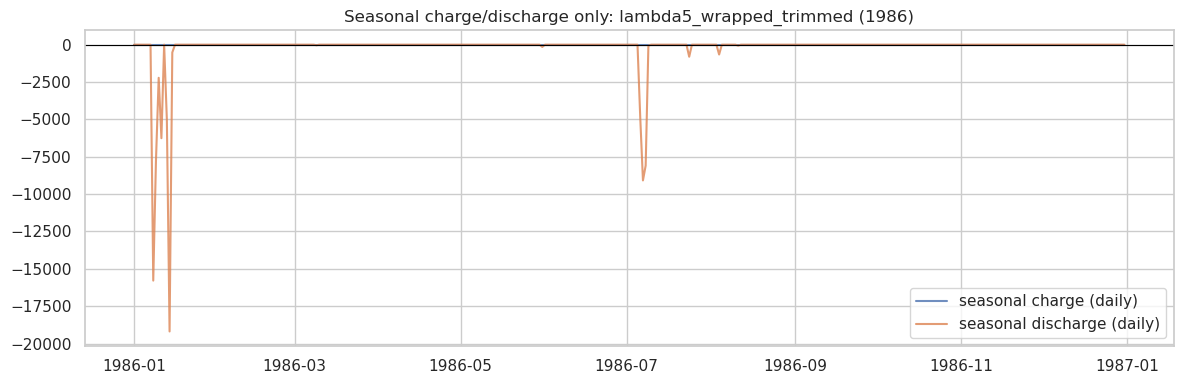

lambda5_wrapped_trimmed (1987) simultaneous hours: 0, days: 0


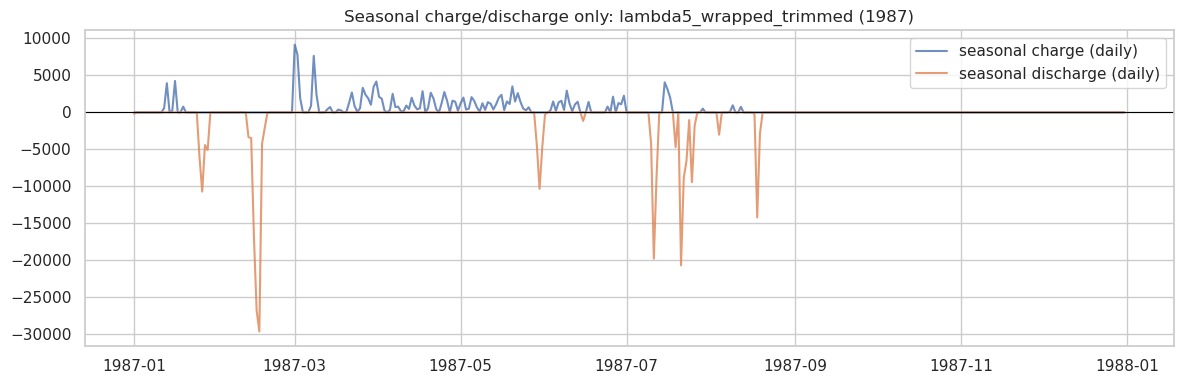

lambda5_wrapped_trimmed (1988) simultaneous hours: 0, days: 0


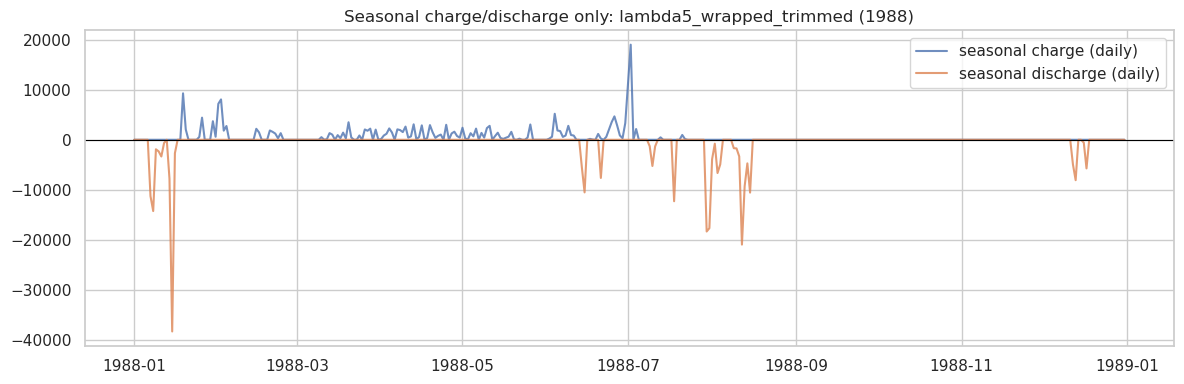

In [9]:
# --- Seasonal charge/discharge only + simultaneous events -------------------
SIMULT_TOL = 1e-6
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        seas_ch = total_ts(data["charge_seasonal"], "charge")
        seas_dis = total_ts(data["discharge_seasonal"], "discharge")
        if seas_ch.empty and seas_dis.empty:
            continue

        # Daily aggregation for readability
        ch = seas_ch.copy()
        dis = seas_dis.copy()
        ch.index = _strip_tz(ch.index)
        dis.index = _strip_tz(dis.index)
        ch_d = ch.resample("D").sum()
        dis_d = dis.resample("D").sum()

        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(ch_d.index, ch_d.values, label="seasonal charge (daily)", alpha=0.8)
        ax.plot(dis_d.index, -dis_d.values, label="seasonal discharge (daily)", alpha=0.8)
        ax.axhline(0.0, color="black", linewidth=0.8)

        # Mark days with any simultaneous seasonal charge + discharge
        simult = (ch > SIMULT_TOL) & (dis > SIMULT_TOL)
        if simult.any():
            simult_days = simult.astype(int).resample("D").max()
            sim_days = simult_days[simult_days > 0].index
            ax.scatter(sim_days, [0.0]*len(sim_days), color="red", marker="x", s=30,
                       label="simultaneous ch/dis (day)")
            print(f"{label} ({year}) simultaneous hours: {int(simult.sum())}, days: {len(sim_days)}")
        else:
            print(f"{label} ({year}) simultaneous hours: 0, days: 0")

        ax.set_title(f"Seasonal charge/discharge only: {label} ({year})")
        ax.legend()
        plt.tight_layout()
        plt.show()


Using storage zones: ['A', 'B', 'D', 'E', 'G', 'J']


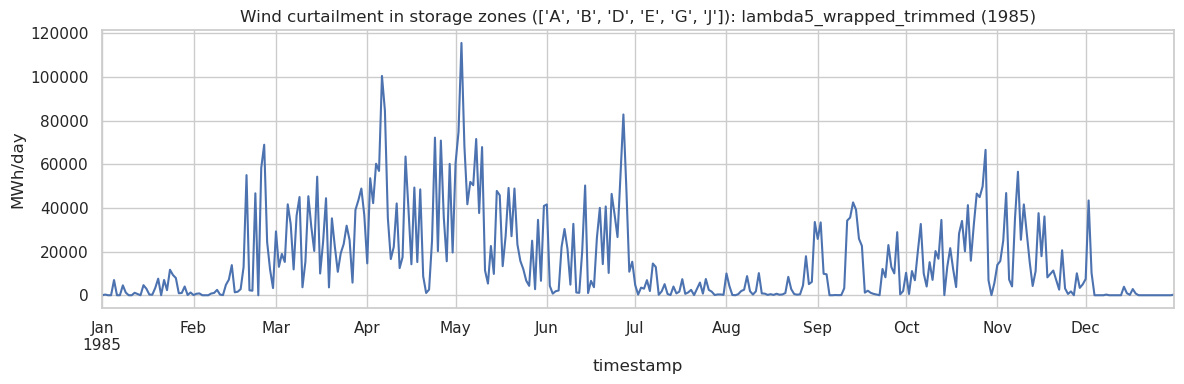

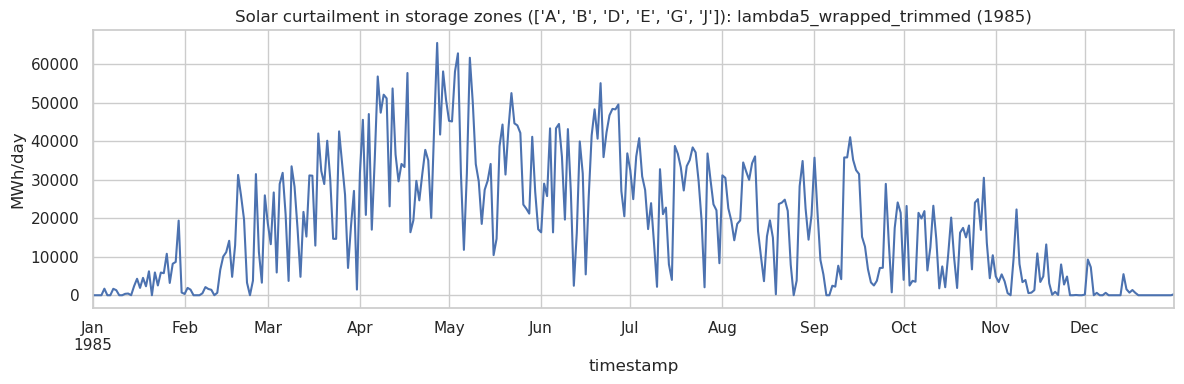

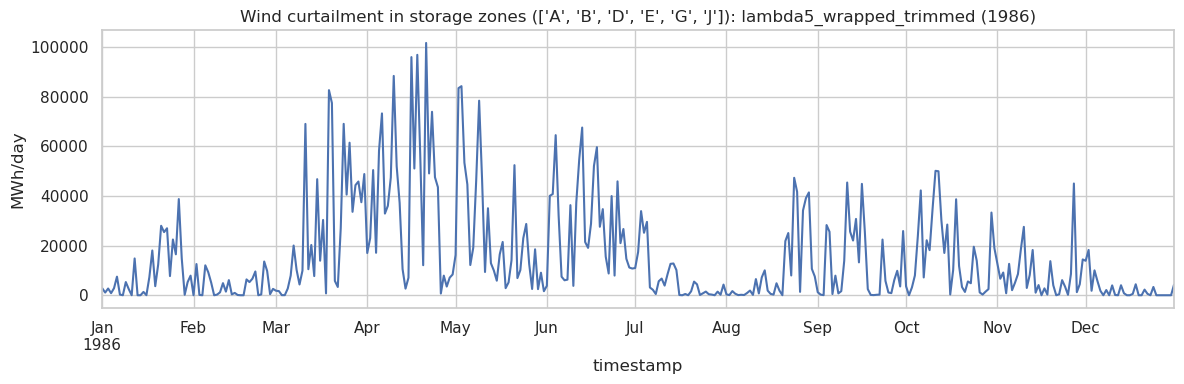

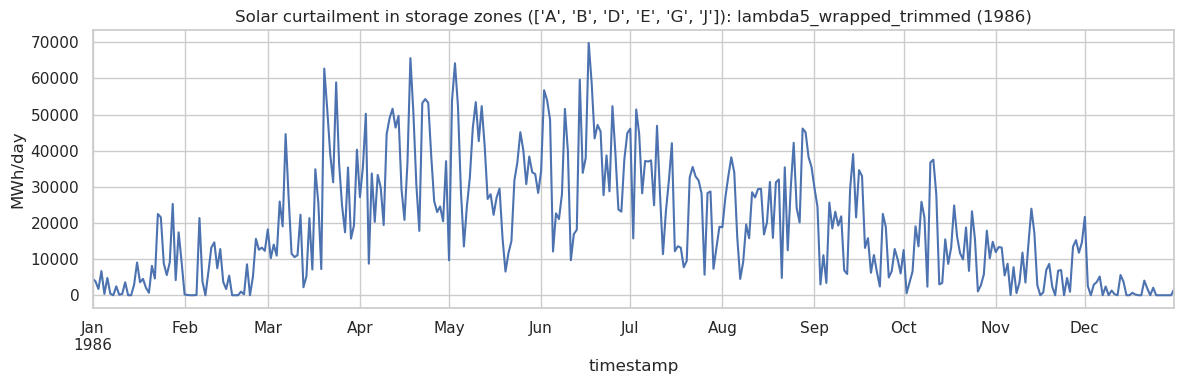

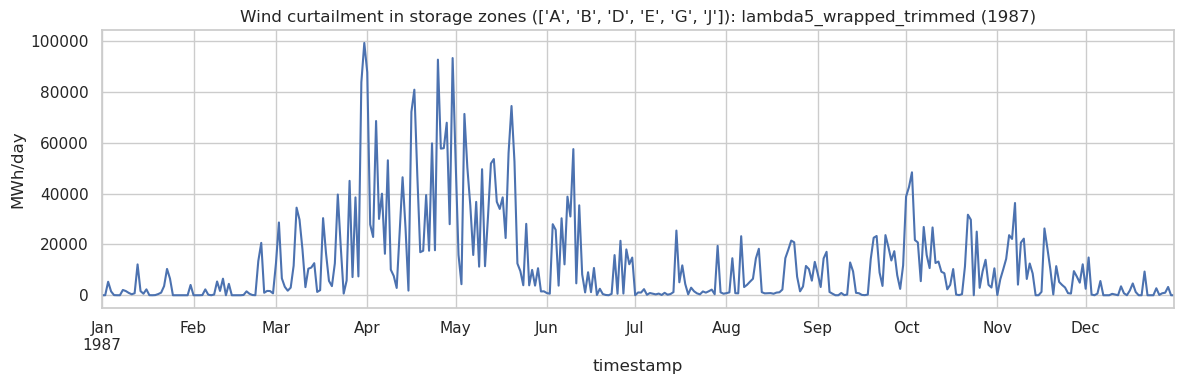

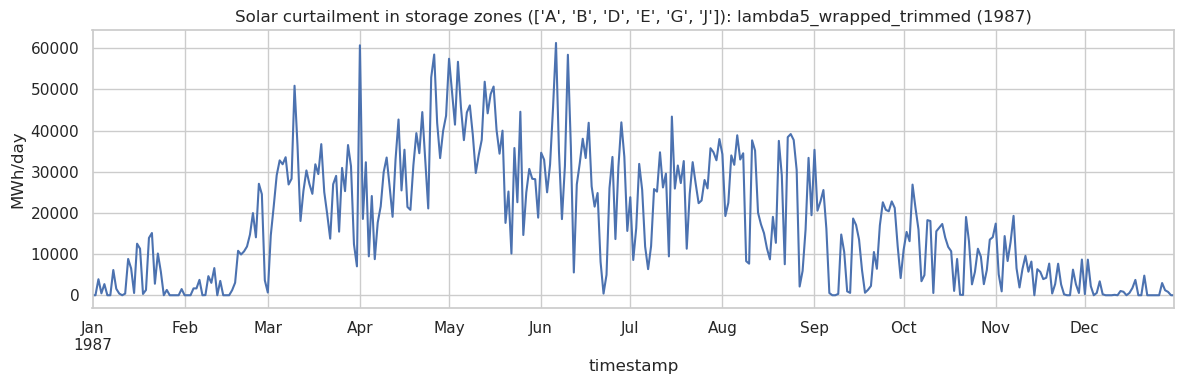

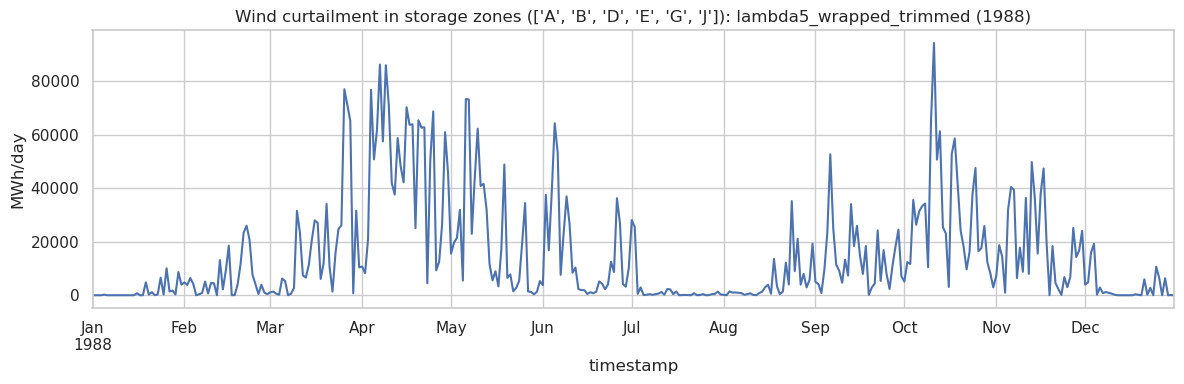

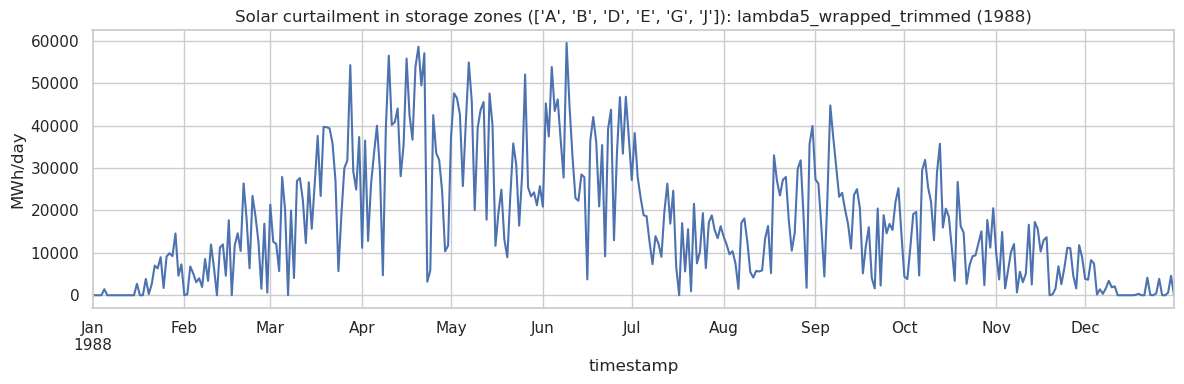

,run,year,wind_curt_MWh_in_storage_zones,solar_curt_MWh_in_storage_zones
0,lambda5_wrapped_trimmed,1985,5994633.23,6711507.54
1,lambda5_wrapped_trimmed,1986,5782274.50,7176553.53
2,lambda5_wrapped_trimmed,1987,4612877.72,6481459.18
3,lambda5_wrapped_trimmed,1988,5546985.44,6421052.83


In [10]:
# --- Curtailment comparison in storage zones -------------------------------
# If STORAGE_ZONES is None, infer from storage activity (seasonal first, then base)
STORAGE_ZONES = None  # e.g., ["A", "B"]


def infer_storage_zones(run_data: dict) -> list:
    zones = set()
    for run, data in run_data.items():
        for df in (data.get("charge_seasonal"), data.get("discharge_seasonal")):
            if df is not None and not df.empty and "zone" in df.columns:
                zones |= set(df["zone"].dropna().unique())
    if not zones:
        for run, data in run_data.items():
            for df in (data.get("charge_base"), data.get("discharge_base")):
                if df is not None and not df.empty and "zone" in df.columns:
                    zones |= set(df["zone"].dropna().unique())
    return sorted(zones)


zones = STORAGE_ZONES if STORAGE_ZONES is not None else infer_storage_zones(run_data)
print("Using storage zones:", zones)

if not zones:
    print("No storage zones detected; set STORAGE_ZONES manually.")
else:
    rows = []
    for run, yearly in run_data_by_year.items():
        label = LABELS.get(run, run)
        for year, data in yearly.items():
            wind_df = data.get("wind_curt")
            solar_df = data.get("solar_curt")

            if wind_df is None or wind_df.empty:
                wind_ts = pd.Series(dtype=float)
            else:
                wind_ts = wind_df[wind_df["zone"].isin(zones)].groupby("timestamp")["wind_curtailment"].sum()
            if solar_df is None or solar_df.empty:
                solar_ts = pd.Series(dtype=float)
            else:
                solar_ts = solar_df[solar_df["zone"].isin(zones)].groupby("timestamp")["solar_curtailment"].sum()

            wind_ts.index = _strip_tz(wind_ts.index)
            solar_ts.index = _strip_tz(solar_ts.index)
            wind_d = wind_ts.resample("D").sum() if not wind_ts.empty else wind_ts
            solar_d = solar_ts.resample("D").sum() if not solar_ts.empty else solar_ts

            if not wind_d.empty:
                ax = wind_d.plot(figsize=(12,4), title=f"Wind curtailment in storage zones ({zones}): {label} ({year})")
                ax.set_ylabel("MWh/day")
                plt.tight_layout()
                plt.show()
            if not solar_d.empty:
                ax = solar_d.plot(figsize=(12,4), title=f"Solar curtailment in storage zones ({zones}): {label} ({year})")
                ax.set_ylabel("MWh/day")
                plt.tight_layout()
                plt.show()

            rows.append({
                "run": label,
                "year": year,
                "wind_curt_MWh_in_storage_zones": float(pd.to_numeric(wind_ts, errors='coerce').fillna(0).sum()),
                "solar_curt_MWh_in_storage_zones": float(pd.to_numeric(solar_ts, errors='coerce').fillna(0).sum()),
            })

    zone_curt_df = pd.DataFrame(rows)
    if not zone_curt_df.empty:
        for c in zone_curt_df.columns[2:]:
            zone_curt_df[c] = zone_curt_df[c].round(2)
        display(zone_curt_df.sort_values(["year", "run"]))
